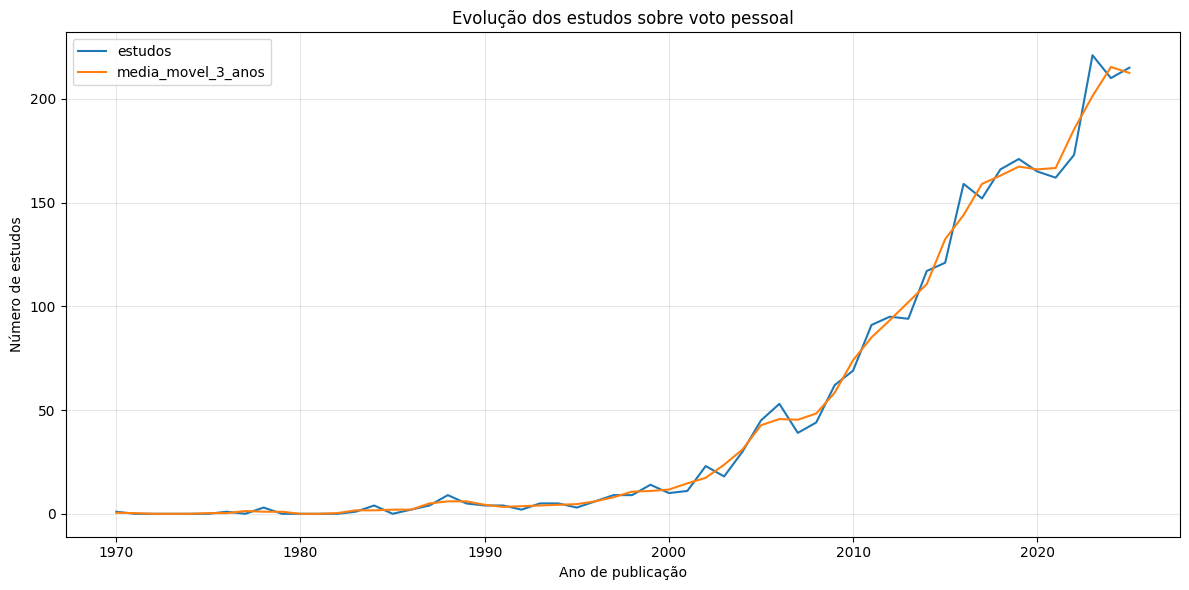

In [1]:
import requests
import pandas as pd
import matplotlib.pyplot as plt

API_KEY = "yAHypbZMlG7vnvWuGGcHGw"

consulta = """
(
    "personal vote"
    OR "personalistic voting"
    OR "candidate-centered voting"
    OR "candidate-centred voting"
    OR "voto pessoal"
    OR "voto personalista"
)
AND
(
    electoral
    OR election
    OR elections
    OR "open-list proportional representation"
    OR "preferential voting"
    OR "lista aberta"
)
""".replace("\n", " ")

url = "https://api.openalex.org/works"

params = {
    "api_key": API_KEY,
    "search": consulta,
    "filter": "publication_year:1970-2025",
    "group_by": "publication_year",
    "per_page": 200
}

response = requests.get(url, params=params, timeout=30)
response.raise_for_status()

dados = response.json()["group_by"]

df = pd.DataFrame(
    {
        "ano": [int(item["key"]) for item in dados],
        "estudos": [item["count"] for item in dados]
    }
)

# Inclui anos sem resultados
anos = pd.DataFrame({"ano": range(1970, 2026)})

df = (
    anos
    .merge(df, on="ano", how="left")
    .fillna({"estudos": 0})
    .sort_values("ano")
)

df["media_movel_3_anos"] = (
    df["estudos"]
    .rolling(window=3, center=True, min_periods=1)
    .mean()
)

ax = df.plot(
    x="ano",
    y=["estudos", "media_movel_3_anos"],
    kind="line",
    figsize=(12, 6)
)

ax.set_title("Evolução dos estudos sobre voto pessoal")
ax.set_xlabel("Ano de publicação")
ax.set_ylabel("Número de estudos")
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()